# Data Coverage: Pre-training vs ADMET Test Set Overlap

Checks whether any SMILES in the ADMET benchmark **test sets** appear in the pre-training datasets.
This is critical for ensuring no data leakage inflates downstream results.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from rdkit import Chem

DATA_DIR = Path('../data')

def canonicalize(smi):
    """Canonicalize a SMILES string via RDKit. Returns None if invalid."""
    try:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            return None
        return Chem.MolToSmiles(mol)
    except:
        return None

def load_smiles(path, smiles_col, name):
    """Load unique canonicalized SMILES from a file."""
    path = Path(path)
    if not path.exists():
        print(f'  SKIP {name}: {path} not found')
        return set()
    if path.suffix == '.parquet':
        df = pd.read_parquet(path, columns=[smiles_col])
    elif path.suffix == '.gz':
        df = pd.read_csv(path, usecols=[smiles_col])
    else:
        df = pd.read_csv(path, usecols=[smiles_col])
    raw = df[smiles_col].dropna().unique()
    canon = set(filter(None, (canonicalize(s) for s in raw)))
    print(f'  {name}: {len(raw):,} raw -> {len(canon):,} canonical SMILES')
    return canon

print('Helpers loaded.')

Helpers loaded.


## 1. Load ADMET test sets

In [2]:
from pathlib import Path as _Path
from tdc.benchmark_group import admet_group

TDC_CACHE = str(_Path('~/.cache/graphium/tdc/ADMET_Benchmark/').expanduser())
group = admet_group(path=TDC_CACHE)

admet_test_smiles = {}   # task -> set of canonical SMILES (test)
admet_train_smiles = {}  # task -> set of canonical SMILES (train+val)
admet_all_test = set()
admet_all_train = set()

for name in group.dataset_names:
    benchmark = group.get(name)
    # Test set
    test_df = benchmark['test']
    raw_test = test_df['Drug'].dropna().unique()
    canon_test = set(filter(None, (canonicalize(s) for s in raw_test)))
    admet_test_smiles[name] = canon_test
    admet_all_test |= canon_test
    # Train+val set
    train_val_df = benchmark['train_val']
    raw_train = train_val_df['Drug'].dropna().unique()
    canon_train = set(filter(None, (canonicalize(s) for s in raw_train)))
    admet_train_smiles[name] = canon_train
    admet_all_train |= canon_train

print(f'Total unique ADMET test SMILES (union across {len(admet_test_smiles)} tasks): {len(admet_all_test):,}')
print(f'Total unique ADMET train+val SMILES (union): {len(admet_all_train):,}')
print()
print(f'{"Task":<40} {"Train+Val":>10} {"Test":>10} {"Total":>10}')
print('-' * 72)
for name in sorted(admet_test_smiles.keys()):
    n_train = len(admet_train_smiles[name])
    n_test = len(admet_test_smiles[name])
    print(f'{name:<40} {n_train:>10,} {n_test:>10,} {n_train + n_test:>10,}')

Found local copy...
[16:41:29] WARNING: not removing hydrogen atom without neighbors
[16:41:29] WARNING: not removing hydrogen atom without neighbors
[16:41:29] WARNING: not removing hydrogen atom without neighbors
[16:41:29] WARNING: not removing hydrogen atom without neighbors
[16:41:29] WARNING: not removing hydrogen atom without neighbors
[16:41:29] WARNING: not removing hydrogen atom without neighbors
[16:41:29] WARNING: not removing hydrogen atom without neighbors
[16:41:29] WARNING: not removing hydrogen atom without neighbors
[16:41:29] WARNING: not removing hydrogen atom without neighbors
[16:41:29] WARNING: not removing hydrogen atom without neighbors
[16:41:29] WARNING: not removing hydrogen atom without neighbors
[16:41:29] WARNING: not removing hydrogen atom without neighbors
[16:41:30] WARNING: not removing hydrogen atom without neighbors
[16:41:30] WARNING: not removing hydrogen atom without neighbors
[16:41:30] WARNING: not removing hydrogen atom without neighbors
[16:4

Total unique ADMET test SMILES (union across 22 tasks): 13,818
Total unique ADMET train+val SMILES (union): 40,229

Task                                      Train+Val       Test      Total
------------------------------------------------------------------------
ames                                          5,802      1,453      7,255
bbb_martins                                   1,581        394      1,975
bioavailability_ma                              512        128        640
caco2_wang                                      725        181        906
clearance_hepatocyte_az                         817        203      1,020
clearance_microsome_az                          881        221      1,102
cyp2c9_substrate_carbonmangels                  531        135        666
cyp2c9_veith                                  9,673      2,419     12,092
cyp2d6_substrate_carbonmangels                  530        134        664
cyp2d6_veith                                 10,504      2,626     13,1

## 2. Load pre-training datasets

In [3]:
SMALL = DATA_DIR / 'graphium/neurips2023/small-dataset'
LARGE = DATA_DIR / 'graphium/neurips2023/large-dataset'

pretrain_datasets = {}

# --- ToyMix ---
print('ToyMix:')
pretrain_datasets['QM9'] = load_smiles(SMALL / 'qm9.csv', 'smiles', 'QM9')
pretrain_datasets['Tox21'] = load_smiles(SMALL / 'Tox21-7k-12-labels.csv', 'smiles', 'Tox21')
pretrain_datasets['ZINC12k'] = load_smiles(SMALL / 'ZINC12k.csv', 'smiles', 'ZINC12k')
pretrain_datasets['ToyMix (all)'] = pretrain_datasets['QM9'] | pretrain_datasets['Tox21'] | pretrain_datasets['ZINC12k']
print(f'  ToyMix total unique: {len(pretrain_datasets["ToyMix (all)"]):,}')

# --- LargeMix ---
print('\nLargeMix:')
pretrain_datasets['L1000 VCAP'] = load_smiles(LARGE / 'LINCS_L1000_VCAP_0-2_th2.csv.gz', 'SMILES', 'L1000 VCAP')
pretrain_datasets['L1000 MCF7'] = load_smiles(LARGE / 'LINCS_L1000_MCF7_0-2_th2.csv.gz', 'SMILES', 'L1000 MCF7')
pretrain_datasets['PCBA'] = load_smiles(LARGE / 'PCBA_1328_1564k.parquet', 'SMILES', 'PCBA')
pretrain_datasets['PCQM4M'] = load_smiles(LARGE / 'PCQM4M_G25_N4.parquet', 'ordered_smiles', 'PCQM4M')
pretrain_datasets['LargeMix (all)'] = (pretrain_datasets['L1000 VCAP'] | pretrain_datasets['L1000 MCF7'] |
                                        pretrain_datasets['PCBA'] | pretrain_datasets['PCQM4M'])
print(f'  LargeMix total unique: {len(pretrain_datasets["LargeMix (all)"]):,}')

# --- RxRx3 ---
print('\nRxRx3:')
pretrain_datasets['RxRx3'] = load_smiles(DATA_DIR / 'rxrx3/rxrx3_smiles_embeddings.csv', 'SMILES_nometa', 'RxRx3')

# --- DTI ---
print('\nDTI:')
pretrain_datasets['DTI'] = load_smiles(DATA_DIR / 'dti-processed/dti_esm2_100k.csv', 'SMILES_nometa', 'DTI')

print(f'\nAll pre-training datasets loaded.')

ToyMix:
  QM9: 133,802 raw -> 133,798 canonical SMILES


[16:41:45] WARNING: not removing hydrogen atom without neighbors


  Tox21: 7,831 raw -> 7,831 canonical SMILES
  ZINC12k: 12,000 raw -> 12,000 canonical SMILES
  ToyMix total unique: 153,226

LargeMix:


[16:41:48] SMILES Parse Error: syntax error while parsing: restricted
[16:41:48] SMILES Parse Error: Failed parsing SMILES 'restricted' for input: 'restricted'


  L1000 VCAP: 15,193 raw -> 15,155 canonical SMILES


...

  PCBA: 1,563,664 raw -> 1,563,664 canonical SMILES


[16:45:56] WARNING: not removing hydrogen atom without neighbors
[16:49:07] WARNING: not removing hydrogen atom without neighbors
[16:49:07] WARNING: not removing hydrogen atom without neighbors
[16:49:07] WARNING: not removing hydrogen atom without neighbors
[16:49:37] WARNING: not removing hydrogen atom without neighbors
[16:49:37] WARNING: not removing hydrogen atom without neighbors
[16:49:37] WARNING: not removing hydrogen atom without neighbors
[16:49:38] WARNING: not removing hydrogen atom without neighbors
[16:49:38] WARNING: not removing hydrogen atom without neighbors


  PCQM4M: 3,452,168 raw -> 3,452,168 canonical SMILES
  LargeMix total unique: 5,017,537

RxRx3:
  RxRx3: 1,672 raw -> 1,672 canonical SMILES

DTI:


[16:50:10] Can't kekulize mol.  Unkekulized atoms: 19 20 22 23 24
[16:50:14] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[16:50:16] Explicit valence for atom # 5 N, 4, is greater than permitted
[16:50:21] Explicit valence for atom # 3 F, 2, is greater than permitted
[16:50:21] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[16:50:22] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[16:50:22] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[16:50:22] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[16:50:23] Can't kekulize mol.  Unkekulized atoms: 6 7 8 10 11 13 14
[16:50:23] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 9 10
[16:50:23] Explicit valence for atom # 6 N, 4, is greater than permitted
[16:50:23] Can't kekulize mol.  Unkekulized atoms: 3 4 6
[16:50:24] Can't kekulize mol.  Unkekulized atoms: 5 6 7 18 19 20 21 22 23


  DTI: 72,183 raw -> 71,773 canonical SMILES

All pre-training datasets loaded.


## 3. Overlap analysis: pre-training dataset vs ADMET test (union)

In [4]:
# Check each pre-training dataset against the union of all ADMET test SMILES
print(f'ADMET test set (union): {len(admet_all_test):,} unique SMILES\n')
print(f'{"Pre-training Dataset":<25} {"Size":>10} {"Overlap":>10} {"% of Test":>10} {"% of Pretrain":>13}')
print('-' * 72)

datasets_to_check = [
    'QM9', 'Tox21', 'ZINC12k', 'ToyMix (all)',
    'L1000 VCAP', 'L1000 MCF7', 'PCBA', 'PCQM4M', 'LargeMix (all)',
    'RxRx3', 'DTI',
]

overlap_results = {}
for ds_name in datasets_to_check:
    ds = pretrain_datasets[ds_name]
    overlap = ds & admet_all_test
    overlap_results[ds_name] = overlap
    pct_test = 100 * len(overlap) / len(admet_all_test) if admet_all_test else 0
    pct_pretrain = 100 * len(overlap) / len(ds) if ds else 0
    marker = ' ⚠' if len(overlap) > 0 else ''
    print(f'{ds_name:<25} {len(ds):>10,} {len(overlap):>10,} {pct_test:>9.1f}% {pct_pretrain:>12.2f}%{marker}')

ADMET test set (union): 13,818 unique SMILES

Pre-training Dataset            Size    Overlap  % of Test % of Pretrain
------------------------------------------------------------------------
QM9                          133,798        193       1.4%         0.14% ⚠
Tox21                          7,831      1,432      10.4%        18.29% ⚠
ZINC12k                       12,000          2       0.0%         0.02% ⚠
ToyMix (all)                 153,226      1,549      11.2%         1.01% ⚠
L1000 VCAP                    15,155        606       4.4%         4.00% ⚠
L1000 MCF7                    11,521        837       6.1%         7.26% ⚠
PCBA                       1,563,664      9,062      65.6%         0.58% ⚠
PCQM4M                     3,452,168          0       0.0%         0.00%
LargeMix (all)             5,017,537      9,107      65.9%         0.18% ⚠
RxRx3                          1,672        473       3.4%        28.29% ⚠
DTI                           71,773        852       6.2%  

## 4. Per-task breakdown for datasets with overlap

In [5]:
# For each pre-training dataset that has overlap, show per-task breakdown
datasets_with_overlap = [ds for ds in datasets_to_check if len(overlap_results[ds]) > 0]

if not datasets_with_overlap:
    print('No overlap found between any pre-training dataset and ADMET test sets!')
else:
    for ds_name in datasets_with_overlap:
        ds = pretrain_datasets[ds_name]
        print(f'\n{"=" * 60}')
        print(f'  {ds_name} — per-task overlap with ADMET test')
        print(f'{"=" * 60}')
        print(f'{"Task":<40} {"Test Size":>10} {"Overlap":>10} {"% Leaked":>10}')
        print('-' * 72)
        for task in sorted(admet_test_smiles.keys()):
            test_set = admet_test_smiles[task]
            overlap = ds & test_set
            pct = 100 * len(overlap) / len(test_set) if test_set else 0
            marker = ' ⚠' if len(overlap) > 0 else ''
            print(f'{task:<40} {len(test_set):>10,} {len(overlap):>10,} {pct:>9.1f}%{marker}')


  QM9 — per-task overlap with ADMET test
Task                                      Test Size    Overlap   % Leaked
------------------------------------------------------------------------
ames                                          1,453         47       3.2% ⚠
bbb_martins                                     394         20       5.1% ⚠
bioavailability_ma                              128          0       0.0%
caco2_wang                                      181          1       0.6% ⚠
clearance_hepatocyte_az                         203          1       0.5% ⚠
clearance_microsome_az                          221          0       0.0%
cyp2c9_substrate_carbonmangels                  135          0       0.0%
cyp2c9_veith                                  2,419          5       0.2% ⚠
cyp2d6_substrate_carbonmangels                  134          0       0.0%
cyp2d6_veith                                  2,626          4       0.2% ⚠
cyp3a4_substrate_carbonmangels                  134        

## 5. Overlap heatmap

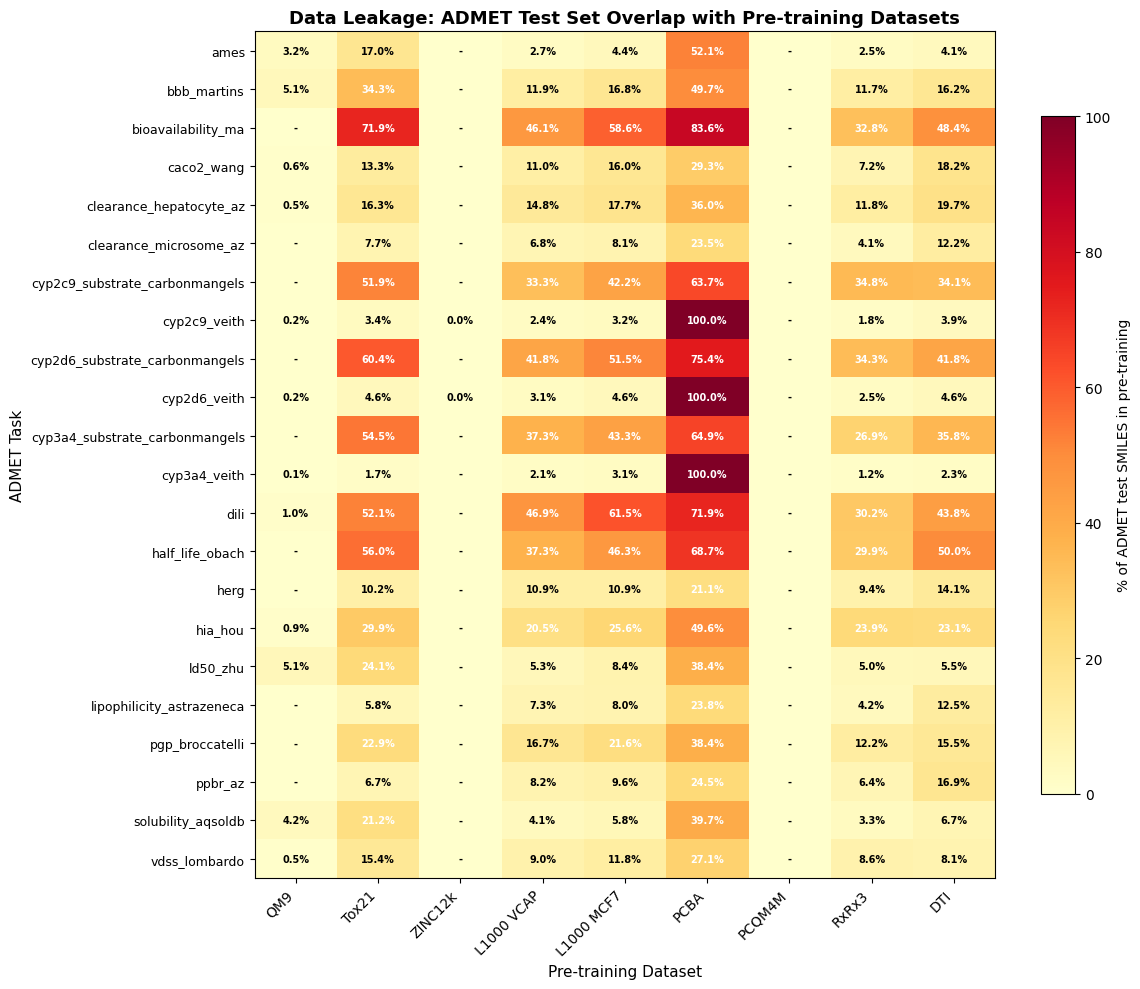


Max overlap: 100.0% (row=cyp2c9_veith, col=PCBA)


In [9]:
import matplotlib.pyplot as plt

# Build overlap matrix: pre-training dataset (cols) x ADMET task (rows)
pretrain_names = ['QM9', 'Tox21', 'ZINC12k', 'L1000 VCAP', 'L1000 MCF7',
                  'PCBA', 'PCQM4M', 'RxRx3', 'DTI']
task_names = sorted(admet_test_smiles.keys())

matrix = np.zeros((len(task_names), len(pretrain_names)))
for i, task in enumerate(task_names):
    test_set = admet_test_smiles[task]
    for j, ds_name in enumerate(pretrain_names):
        ds = pretrain_datasets[ds_name]
        overlap = ds & test_set
        matrix[i, j] = 100 * len(overlap) / len(test_set) if test_set else 0

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd', vmin=0)

ax.set_xticks(range(len(pretrain_names)))
ax.set_xticklabels(pretrain_names, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(task_names)))
ax.set_yticklabels(task_names, fontsize=9)

# Annotate cells with overlap %
for i in range(len(task_names)):
    for j in range(len(pretrain_names)):
        val = matrix[i, j]
        if val > 0:
            color = 'white' if val > 20 else 'black'
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                    fontsize=7, color=color, fontweight='bold')
        else:
            color = 'white' if val > 20 else 'black'
            ax.text(j, i, '-', ha='center', va='center',
                    fontsize=7, color=color, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('% of ADMET test SMILES in pre-training', fontsize=10)

ax.set_title('Data Leakage: ADMET Test Set Overlap with Pre-training Datasets',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Pre-training Dataset', fontsize=11)
ax.set_ylabel('ADMET Task', fontsize=11)

plt.tight_layout()
plt.show()

if matrix.max() == 0:
    print('\nNo overlap detected — all clean!')
else:
    print(f'\nMax overlap: {matrix.max():.1f}% (row={task_names[matrix.max(axis=1).argmax()]}, '
          f'col={pretrain_names[matrix.max(axis=0).argmax()]})')

## 6. Summary

In [7]:
# Final summary
all_pretrain = set()
for ds_name in ['ToyMix (all)', 'LargeMix (all)', 'RxRx3', 'DTI']:
    all_pretrain |= pretrain_datasets[ds_name]

total_overlap = all_pretrain & admet_all_test
print(f'Total unique pre-training SMILES (all datasets): {len(all_pretrain):,}')
print(f'Total unique ADMET test SMILES (all tasks):      {len(admet_all_test):,}')
print(f'Overlap (SMILES in both):                        {len(total_overlap):,}')
print(f'  = {100*len(total_overlap)/len(admet_all_test):.1f}% of ADMET test')
print(f'  = {100*len(total_overlap)/len(all_pretrain):.4f}% of pre-training')

if total_overlap:
    print(f'\n⚠ WARNING: {len(total_overlap)} ADMET test SMILES found in pre-training data.')
    print('Overlapping SMILES (first 20):')
    for smi in sorted(total_overlap)[:20]:
        print(f'  {smi}')
else:
    print('\n✓ No data leakage detected.')

Total unique pre-training SMILES (all datasets): 5,227,880
Total unique ADMET test SMILES (all tasks):      13,818
Overlap (SMILES in both):                        9,358
  = 67.7% of ADMET test
  = 0.1790% of pre-training

⚠ WARNING: 9358 ADMET test SMILES found in pre-training data.
Overlapping SMILES (first 20):
  Br.CC(C)CC1CC(=O)OC1(C)C(=O)CSc1nc2ccccc2s1
  Br.CCCCCCCCCCn1c2c(c(=N)c3c1CCC3)CCC2
  Br.CCCCCCN1Cc2ccccc2C1
  Br.CC[C@H]1CN2CC[C@@H]1C[C@H]2[C@@H](O)c1ccnc2ccc(OC)cc12.O
  Br.C[N+](C)(C)CCCCCNCC12CC3CC(CC(C3)C1)C2.[Br-]
  Br.N=C1c2ccccc2CN1NC(=O)c1ccc(Cl)cc1
  Br.N=C1c2ccccc2CN1NC(=O)c1ccc(F)cc1
  BrC(Br)Br
  BrC(c1cccc2ccccc12)c1cccc2ccccc12
  BrCC(Br)C1CCC(Br)C(Br)C1
  BrCC1CO1
  BrCc1c2ccccc2cc2ccccc12
  Brc1c(Br)c(Br)c(Oc2c(Br)c(Br)c(Br)c(Br)c2Br)c(Br)c1Br
  Brc1cc(Br)c(-c2c(Br)cc(Br)cc2Br)c(Br)c1
  Brc1ccc(-c2ccccc2)cc1
  Brc1ccc(-c2csc(N3CCC(c4ccccc4)C3)n2)cc1
  Brc1ccc(-c2nnc(-c3ccccc3)c(N3CCSCC3)n2)cc1
  Brc1ccc(CSc2nccn2-c2ccccc2)cc1
  Brc1ccc2ccccc2c1
  Brc1ccc2n